In [47]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('/zhome/71/c/146676/main/')
import SimpleITK as sitk
from loaders import loader_XA_to_NA
import importlib
importlib.reload(loader_XA_to_NA)
import tifffile
import SimpleITK
from loaders import stitcher_XA
from helpers import module_auxiliary as ma
from PIL import Image
import imageio.v3 as iio
Image.MAX_IMAGE_PIXELS = None 
!pip install python-pptx
from pptx import Presentation
import json
from PIL import Image
import IPython.display as display
from scipy.ndimage import gaussian_filter
%matplotlib inline

In [75]:
# 15 distinct, bright RGB colors
import matplotlib.colors as mcolors
colors = [
    (255, 0, 0),      # Red
    (0, 255, 0),      # Green
    (0, 0, 255),      # Blue
    (255, 255, 0),    # Yellow
    (255, 165, 0),    # Orange
    (255, 0, 255),    # Magenta
    (0, 255, 255),    # Cyan
    (128, 0, 128),    # Purple
    (0, 128, 128),    # Teal
    (128, 128, 0),    # Olive
    (255, 105, 180),  # Pink
    (139, 69, 19),    # Brown
    (75, 0, 130),     # Indigo
    (0, 255, 127),     # Spring Green
    (127, 127, 127)   # Grey
]

# Convert to [0,1] scale for matplotlib
colors = [(r/255, g/255, b/255) for r, g, b in colors]
# Generate colormaps that transition from black to each color
colormaps = []
for color in colors:
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", [(0, 0, 0), color])
    colormaps.append(cmap)


In [49]:
path = '/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/'
pre = 'Mosaic element_'
pre = 'eds'
images = []
names = [pre + 'Al.tiff', pre + 'Ca.tiff',pre + 'Cl.tiff', pre + 'Cr.tiff', pre + 'Fe.tiff',
                    pre + 'K.tiff', pre + 'Mg.tiff', pre + 'Na.tiff', pre + 'Ni.tiff',
                    pre + 'O.tiff', pre + 'P.tiff', pre + 'S.tiff', pre + 'Si.tiff',
                    pre + 'Ti.tiff', pre + 'Zr.tiff']
for i in range(len(names)):
    images.append(tifffile.imread(path + names[i]))
images = np.stack(images)
images = np.stack(images)
images[images>150]=0
images[0,images[0]>15]=0
factor = np.linspace(10,30,nx)
images_d[0] = images_d[0]*factor[np.newaxis,:]
factor = np.linspace(1,1.4,nx)
images_d[1:] = images_d[:1]*factor[np.newaxis, np.newaxis,:]
print(np.shape(images))

(15, 15484, 12341)


In [50]:
images_d = images[:,::2,::2]
n_chan, ny, nx = np.shape(images_d)

## Uncomment this to see the bias
#nn = 8
#plt.imshow(images_d[nn]*factor[np.newaxis,:])
#plt.clim([0,30])
#plt.show()
#means = np.mean(factor[np.newaxis,:]*images_d[nn,3000:6000],axis=0)
#plt.plot(means)
#plt.show()

In [51]:
n_filter = 4
filters = [2, 5, 10, 20]
f_im = np.empty((n_filter, n_chan, ny, nx))
for i in range(n_filter):
    print('Applying filter with sd', filters[i])
    for j in range(n_chan):
        f_im[i, j, :,:] = gaussian_filter(images_d[j], sigma = filters[i])


Applying filter with sd 2
Applying filter with sd 5
Applying filter with sd 10
Applying filter with sd 20


Step 1, take only ::3 pixel in each direction. Size is larger than necessary.Step 2: Make a 4d array, where the 4th axis is the amount of smoothing done on the image....

In [52]:
elements = ['Al', 'Ca', 'Cl', 'Cr', 'Fe',  'K', 'Mg', 'Na', 'Ni',  'O',  'P',  'S', 'Si', 'Ti', 'Zr']
                      #[Al, Ca, Cl, Cr, Fe,  K, Mg, Na, Ni,  O,  P,  S, Si, Ti, Zr]
thresholds = np.array([0.7, 15, 15, 6 , 20, 10, 30, 12, 5 , 30, 10, 5 , 30, 10, 3])
for i in range(n_chan):
    f_segm = f_im>thresholds[np.newaxis,:,np.newaxis, np.newaxis]

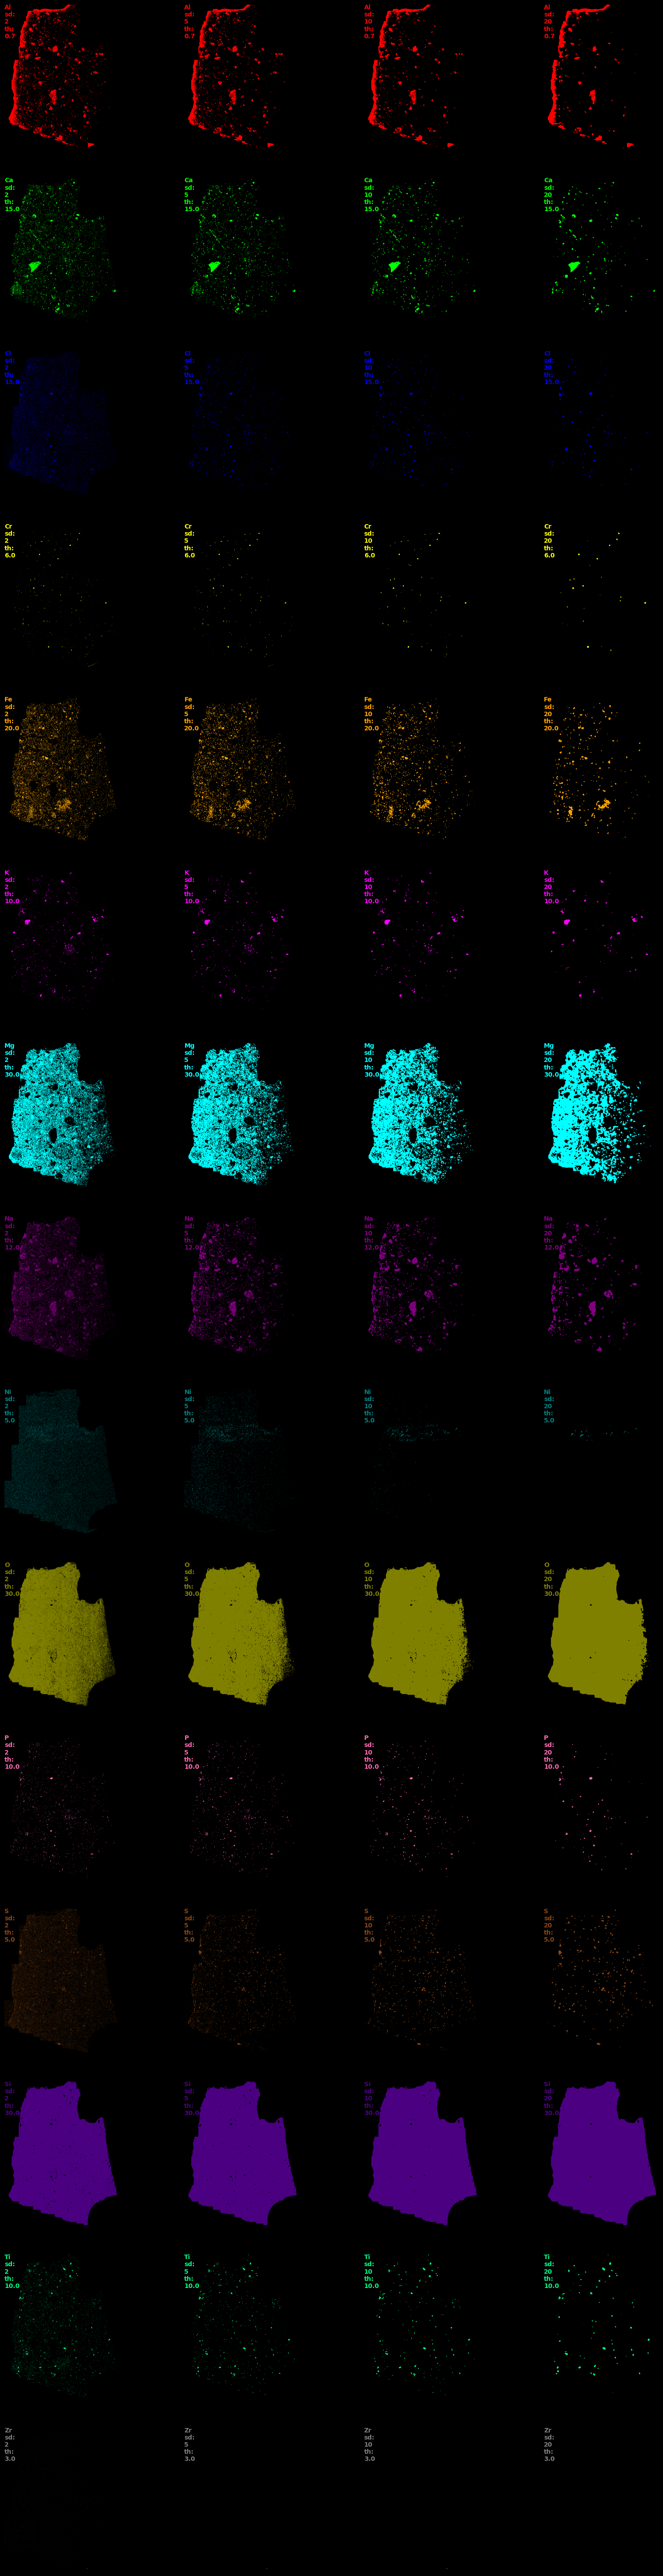

In [53]:
plt.close("all")
N = 15
fig, axes = plt.subplots(N, 4, figsize=(20,int(20/4*N))) 
fig.patch.set_facecolor('black')  # Set the background color to black


for i in range(N):
    for j in range(4):
        im0 = axes[i,j].imshow(f_segm[j,i],cmap=colormaps[i])
        axes[i,j].axis('off')
        # Add text in top-left corner
        axes[i,j].text(0, 0, elements[i] + '\nsd:\n' +str(filters[j]) + '\nth:\n' + str(thresholds[i]), color=colors[i], fontsize=10, ha="left", va="top", fontweight="bold")

plt.show(block=False)

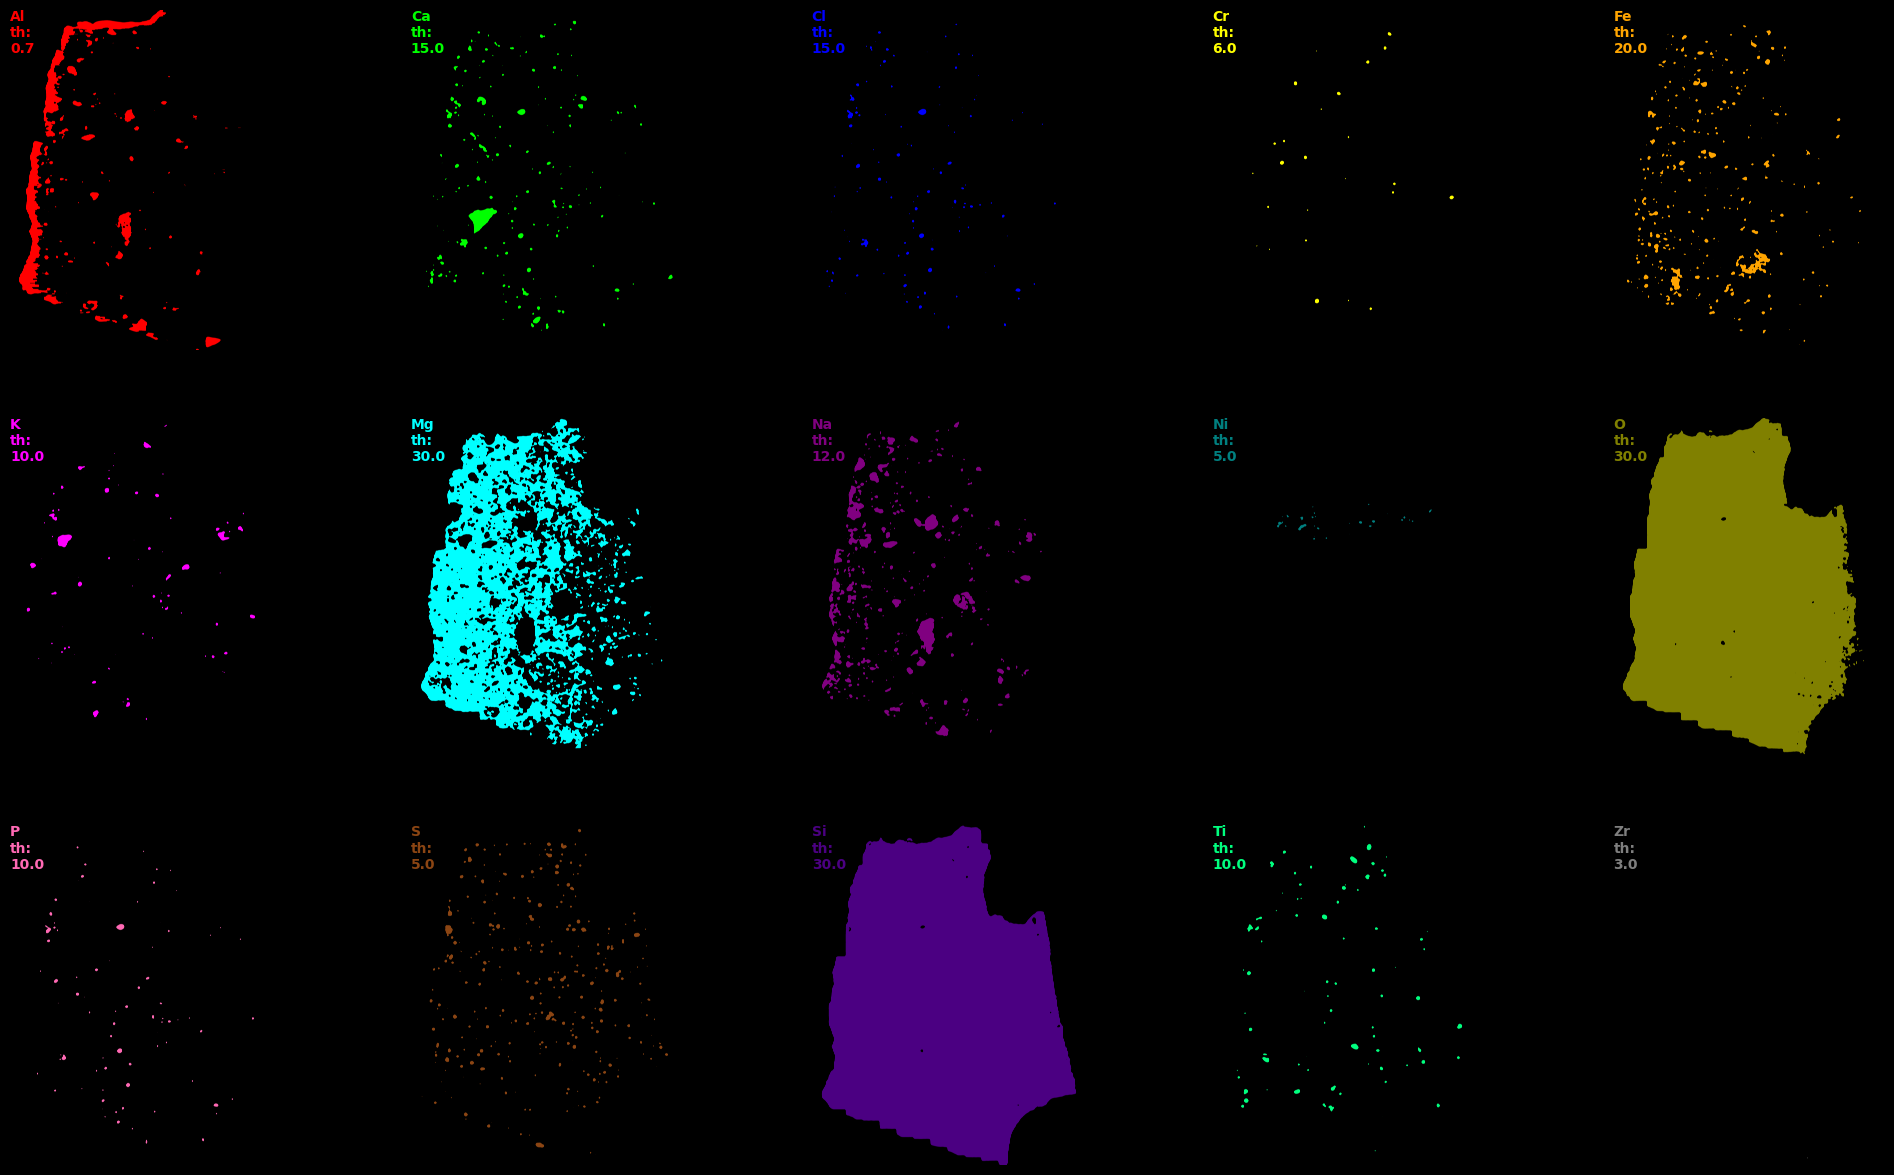

In [76]:
m_segm = f_segm[3]*f_segm[3]
elem_segm = {}
for i in range(n_chan):
    elem_segm[elements[i]] = m_segm[i]
    
plt.close("all")
N = 15
fig, axes = plt.subplots(3, 5, figsize=(25,15)) 
fig.patch.set_facecolor('black')  # Set the background color to black


for i in range(N):
    
    i_x = i%5
    i_y = i//5
    im0 = axes[i_y,i_x].imshow(m_segm[i],cmap=colormaps[i])
    axes[i_y,i_x].axis('off')
    # Add text in top-left corner
    axes[i_y,i_x].text(0, 0, elements[i] + '\nth:\n' + str(thresholds[i]), color=colors[i], fontsize=10, ha="left", va="top", fontweight="bold")

plt.show(block=False)

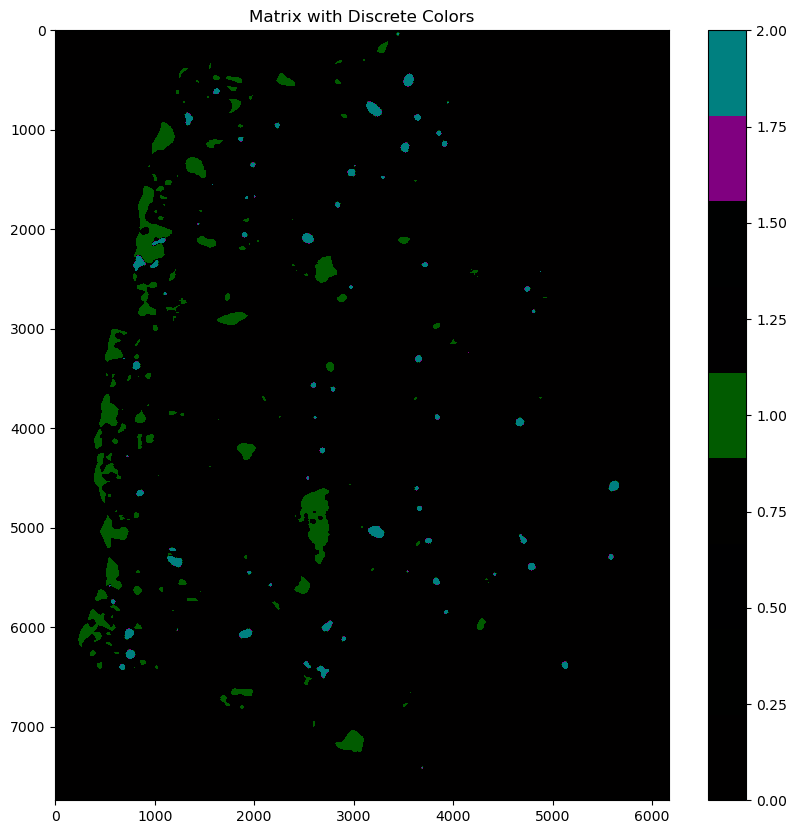

In [77]:
full_seg = np.zeros((ny,nx))
full_seg[elem_segm["Al"]*elem_segm["Na"]] =1
full_seg[elem_segm["Ti"]] =2

# Add black as the first color
colors = [
    (255, 0, 0),      # Red
    (0, 255, 0),      # Green
    (0, 0, 255),      # Blue
    (255, 255, 0),    # Yellow
    (255, 165, 0),    # Orange
    (255, 0, 255),    # Magenta
    (0, 255, 255),    # Cyan
    (128, 0, 128),    # Purple
    (0, 128, 128),    # Teal
    (128, 128, 0),    # Olive
    (255, 105, 180),  # Pink
    (139, 69, 19),    # Brown
    (75, 0, 130),     # Indigo
    (0, 255, 127),     # Spring Green
    (127, 127, 127)   # Grey
]
#colors = [(0, 0, 0)] + colors
# Create a ListedColormap
cmap = mcolors.ListedColormap(colors[0:9])
# Plot the matrix with the custom colormap
plt.figure(figsize=(10,10))
plt.imshow(full_seg, cmap=cmap)
plt.colorbar()  # Show color bar
plt.title("Matrix with Discrete Colors")
plt.show()

Some info regarding the elemental composition of minerals is needed:
Plagioclase (Albite-Anorthite). Mg-Al-Ca (on the slides). 

Albite (NaAlSi₃O₈),  (Al is an identifyer)
Anorthite (CaAl₂Si₂O₈) (Al is an identifyer)
Orthoclase (KAlSi₃O₈) (Al is an identifyer)
Clinopyroxene (Mg2 Si2 O6) or (Ca Mg Si2 O6), (Ca is a weak identifyer)
Orthopyroxene (Mg2 Si2 O6) or (Fe2 Si2 O6) (No clear identifyer discovered)
Chlorapatite (Ca5(PO4)3 Cl) (C + Cl + P) is a clear identifyer
Chromite (Fe Cr2 O4) (Cr is a unique identifyer, and Fe is also an identifyer)
Ilminite (Fe Ti O3) (Ti is a unique identifyer)
Pyrite (Fe S2) (S is a unique identifyer)

In [56]:
#Ordering of the elements:
#[Al, Ca, Cl, Cr, Fe, K, Mg, Na, Ni, O, P, S, Si, Ti, Zr]

Al, Ca, Cl, Cr, Fe, K, Mg, Na, Ni, O, P, S, Si, Ti, Zr = 0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
albite = [1, Ca, Cl, Cr, Fe, K, Mg, 1, Ni, 8, P, S, 3, Ti, Zr]
anorthite = [2, 1, Cl, Cr, Fe, K, Mg, Na, Ni, 8, P, S, 2, Ti, Zr]
orthoclase = [1, Ca, Cl, Cr, Fe, 1, Mg, Na, Ni, 8, P, S, 3, Ti, Zr]
clinopyroxene = [Al, 1, Cl, Cr, Fe, K, 2, Na, Ni, 6, P, S, 2, Ti, Zr]
orthopyroxene = [Al, Ca, Cl, Cr, 2, K, 2, Na, Ni, 6, P, S, 2, Ti, Zr]
chlorapatite = [Al, 5, 2, Cr, Fe, K, Mg, Na, Ni, 12, 3, S, Si, Ti, Zr]
chromite = [Al, Ca, Cl, 2, 1, K, Mg, Na, Ni, 4, P, S, Si, Ti, Zr]
ilminite = [Al, Ca, Cl, Cr, 1, K, Mg, Na, Ni, 3, P, S, Si, 1, Zr]
pyrite = [Al, Ca, Cl, Cr, 1, K, Mg, Na, Ni, O, P, 2, Si, Ti, Zr]
nothing = [Al, Ca, Cl, Cr, Fe, K, Mg, Na, Ni, O, P, S, Si, Ti, Zr]
basis = np.array([albite, anorthite, orthoclase, clinopyroxene, orthopyroxene, chlorapatite, chromite, ilminite, pyrite, nothing])
